## Data loading

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes(as_frame=True)
df = pd.concat([data['data'], data['target']], axis=1)

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


## Data exploration

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
CATEGORICAL_FEATURES = [
    'sex'
]
NUMERICAL_FEATURES = [
    'age', 'bmi', 's1', 's2', 's3', 's4', 's5', 's6'
]
TARGET = 'target'

In [5]:
df[CATEGORICAL_FEATURES].T.apply(lambda row: list(row.unique()), axis=1).to_dict()

{'sex': [0.05068011873981862, -0.044641636506989144]}

### Significance analysis

In [6]:
from typing import List, Literal
from scipy.stats import mannwhitneyu, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

def box_and_whisker(
    data: list, 
    title: str, 
    ylabel: str, 
    xticklabels: List[str],
    variable_type: Literal['continuous', 'categorical']
):
    ax = plt.axes()
    bp = ax.boxplot(data, widths=0.6, patch_artist=True)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(xticklabels)
    ax.tick_params(axis='x', which='major', length=0)
    xticks = [0.5] + [x + 0.5 for x in ax.get_xticks()]
    ax.set_xticks(xticks, minor=True)
    ax.tick_params(axis='x', which='minor', length=3, width=1)

    colors = sns.color_palette('pastel')
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    plt.setp(bp['medians'], color='k')

    significant_combinations = []
    ls = list(range(1, len(data) + 1))
    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    for c in combinations:
        data1 = data[c[0] - 1]
        data2 = data[c[1] - 1]
        
        # Significance
        if variable_type == 'continuous':
            _, p = mannwhitneyu(data1, data2)
        elif variable_type == 'categorical':
            categories = set(data1 + data2)
            p = chi2_contingency(
                [
                    [data1.count(c) for c in categories], 
                    [data2.count(c) for c in categories]
                ]
            ).pvalue
        else:
            raise ValueError('`variable_type` argument can take only two values: "continuous" and "categorical"')
            
        if p < 0.05:
            significant_combinations.append([c, p])

    bottom, top = ax.get_ylim()
    yrange = top - bottom

    # Significance bars
    for i, significant_combination in enumerate(significant_combinations):
        x1 = significant_combination[0][0]
        x2 = significant_combination[0][1]

        level = len(significant_combinations) - i
        bar_height = (yrange * 0.08 * level) + top
        bar_tips = bar_height - (yrange * 0.02)
        plt.plot(
            [x1, x1, x2, x2],
            [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k')

        p = significant_combination[1]
        if p < 0.001:
            sig_symbol = '***'
        elif p < 0.01:
            sig_symbol = '**'
        elif p < 0.05:
            sig_symbol = '*'
        text_height = bar_height + (yrange * 0.01)
        plt.text((x1 + x2) * 0.5, text_height, sig_symbol, ha='center', c='k')

    bottom, top = ax.get_ylim()
    yrange = top - bottom
    ax.set_ylim(bottom - 0.02 * yrange, top)

    # Annotate sample size below each box
    for i, dataset in enumerate(data):
        sample_size = len(dataset)
        ax.text(i + 1, bottom, fr'n = {sample_size}', ha='center', size='x-small')

    plt.show()

In [7]:
def importance_plot(
    df: pd.DataFrame, 
    grouping_variable: str,
    target: str,
    variable_type: Literal['continuous', 'categorical']
):
    feature_groups = df.groupby(grouping_variable).apply(
        lambda group: group[tested_variable].to_list(), 
        include_groups=False
    ).to_dict()
    box_and_whisker(
        data=list(feature_groups.values()), 
        title=f'{} grouped by `{grouping_variable}`', 
        ylabel=tested_variable, 
        xticklabels=list(feature_groups.keys()),
        variable_type=variable_type
    )

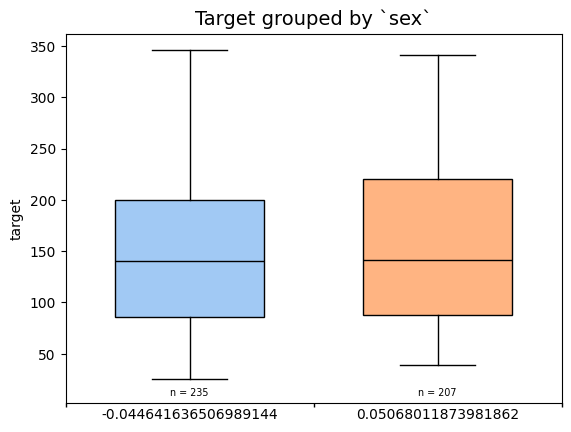

In [8]:
# Categorical features are tested using Chi-square test, whereas continuous using Mann-Whitney U test
for feature in CATEGORICAL_FEATURES:
    importance_plot(
        df=df, 
        grouping_variable=feature,
        tested_variable=TARGET,
        variable_type='categorical'
    )

### Correllation analysis

In [9]:
# Simple categorical variables encoding
from copy import deepcopy
from sklearn.preprocessing import LabelEncoder

encoded_df = deepcopy(df)
label_encoders = {}
for feature in CATEGORICAL_FEATURES + [TARGET]:
    le = LabelEncoder()
    encoded_df[feature] = le.fit_transform(encoded_df[feature])
    label_encoders[feature] = le

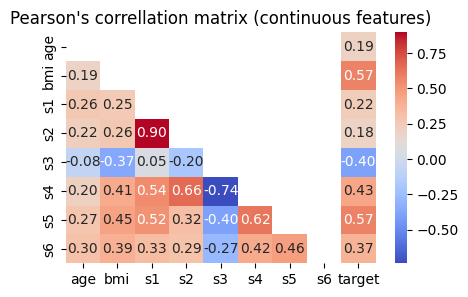

In [14]:
import numpy as np

# Pearson's correllation for continuous variables
plt.figure(figsize=(5, 3))

corr = encoded_df[NUMERICAL_FEATURES + [TARGET]].corr().iloc[:-1]
mask = np.triu(np.ones_like(corr, dtype=bool))
mask[:, -1] = ~mask[:, -1]

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson's correllation matrix (continuous features)")
plt.show()

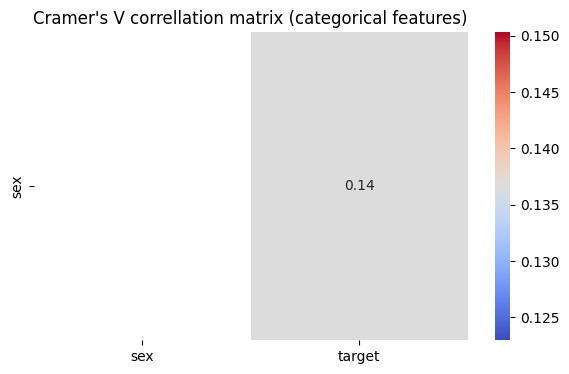

In [15]:
# Cramer's V correllation for continuous variables
def cramers_v(vector_1, vector_2):
    confusion_matrix = pd.crosstab(vector_1, vector_2)
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    n = confusion_matrix.to_numpy().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

plt.figure(figsize=(7, 4))

corr = encoded_df[CATEGORICAL_FEATURES + [TARGET]].corr(method=cramers_v).iloc[:-1]
mask = np.triu(np.ones_like(corr, dtype=bool))
mask[:, -1] = ~mask[:, -1]

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Cramer's V correllation matrix (categorical features)")
plt.show()

## Modelling

In [ ]:
import warnings

from tqdm.auto import tqdm, trange
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import KFold

SELECTED_CATEGORICAL_FEATURES = list(set(CATEGORICAL_FEATURES) & set(SELECTED_FEATURES))
SELECTED_NUMERICAL_FEATURES = list(set(NUMERICAL_FEATURES) & set(SELECTED_FEATURES))

def train_and_evaluate_model(model) -> List[np.ndarray]:
    warnings.filterwarnings('ignore')

    precisions = []
    recalls = []
    f1_scores = []
    
    # We perform 5-folds cross validation 5 times randomly shuffling the dataset 
    # after each validation to ensure the results aren't just a matter of random
    kf = KFold(n_splits=5)
    for _ in trange(5, desc='Cross validation'):
        shuffled_df = ground_df.sample(frac=1)[SELECTED_FEATURES + [TARGET]]
        for train_index, test_index in tqdm(list(kf.split(shuffled_df)), desc='Splits evaluation', leave=False):
            y_train = shuffled_df.iloc[train_index][TARGET]
            y_test = shuffled_df.iloc[test_index][TARGET]
        
            # since we're interested in successfully ended contacts we can join 
            # `unknown` and `failure` outcomes making it a binary classification task
            y_train = y_train.apply(lambda outcome: 1 if outcome == 'success' else 0)
            y_test = y_test.apply(lambda outcome: 1 if outcome == 'success' else 0)
            
            # one-hot encoding for categorical variables
            one_hot_encoders = {}
            for feature in SELECTED_CATEGORICAL_FEATURES:
                encoder = OneHotEncoder()
                encoder.fit(shuffled_df.iloc[train_index][[feature]])
                one_hot_encoders[feature] = encoder
        
            X_train = shuffled_df.iloc[train_index][SELECTED_NUMERICAL_FEATURES].to_numpy()
            X_test = shuffled_df.iloc[test_index][SELECTED_NUMERICAL_FEATURES].to_numpy()
            for feature in SELECTED_CATEGORICAL_FEATURES:
                X_train = np.concatenate(
                    [X_train, one_hot_encoders[feature].transform(shuffled_df.iloc[train_index][[feature]]).toarray()], 
                    axis=1
                )
                X_test = np.concatenate(
                    [X_test, one_hot_encoders[feature].transform(shuffled_df.iloc[test_index][[feature]]).toarray()], 
                    axis=1
                )
        
            model.fit(
                X=X_train,
                y=y_train
            )
            y_pred = model.predict(X=X_test)
        
            precisions.append(precision_score(y_test, y_pred, average='weighted'))
            recalls.append(recall_score(y_test, y_pred, average='weighted'))
            f1_scores.append(f1_score(y_test, y_pred, average='weighted'))
            
    warnings.resetwarnings()
    return np.array(precisions), np.array(recalls), np.array(f1_scores)

In [ ]:
def print_result(
    precisions: np.ndarray, 
    recalls: np.ndarray, 
    f1_scores: np.ndarray, 
    name: str = ''
) -> None:
    result =(f'{name}\n' if name != '' else '') + (
        f'P:  {precisions.mean():.2f} ± {precisions.std():.2f}\n'
        f'R:  {recalls.mean():.2f} ± {recalls.std():.2f}\n'
        f'F1: {f1_scores.mean():.2f} ± {f1_scores.std():.2f}'
    )
    print(result)

According to the paper _[Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology._ for the task of contact outcome prediction best results achieves SVM model.

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.kernel_approximation import Nystroem

model = LinearSVC()
precisions, recalls, f1_scores = train_and_evaluate_model(model)
print_result(precisions, recalls, f1_scores, name='Eval results for SVM model')

Not bad. The results are comparable to the mentioned paper, but let's also try something else

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model = GradientBoostingClassifier(n_estimators=300, subsample=0.3)
precisions, recalls, f1_scores = train_and_evaluate_model(model)
print_result(precisions, recalls, f1_scores, name='Eval results for stochastic gradiend boosting model')